In [1]:
import numpy as np
import matplotlib.pyplot as plt

from cloelite.input import reader
from cloelite.cosmology import camb_cosmology
from cloelite.observables import spectro
from copy import deepcopy

import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=14)

In [2]:
def transform_dict(dictionary):
    dictionary_new = deepcopy(dictionary)
    if dictionary_new['As']<1e-7: dictionary_new['As'] *= 1e9
    if 'H0' in dictionary_new.keys(): dictionary_new['h'] = dictionary_new.pop('H0') / 100.0
    if 'omch2' in dictionary_new.keys(): dictionary_new['wc'] = dictionary_new.pop('omch2')
    if 'ombh2' in dictionary_new.keys(): dictionary_new['wb'] = dictionary_new.pop('ombh2')
    return dictionary_new

In [3]:
params_reader = reader.ParamsReader('../../cloelite/input/parameters.yaml')
H0 = params_reader.get_section('cosmology')['H0']
h = H0 / 100.0
ombh2 = params_reader.get_section('cosmology')['ombh2']
omch2 = params_reader.get_section('cosmology')['omch2']
ns = params_reader.get_section('cosmology')['ns']
As = params_reader.get_section('cosmology')['As']
background = camb_cosmology.CAMBBackground(H0=H0, ombh2=ombh2, omch2=omch2, ns=ns, As=As, w=-1.0, wa=0.0, Omk=0.0, sigma8=0.0, gamma_MG=0.0)
linear_perturbations = camb_cosmology.CAMBLinearPerturbations(background=background, redshifts=np.linspace(0.0, 4.0, 256))
background_fiducial = camb_cosmology.CAMBBackground(H0=H0, ombh2=ombh2, omch2=omch2*1.1, ns=ns, As=As, w=-1.0, wa=0.0, Omk=0.0, sigma8=0.0, gamma_MG=0.0)
mps_spectro = spectro.LegendreMultipoles(NLcode='COMET', linear_perturbations=linear_perturbations, background_fiducial=background_fiducial)
mps_spectro.set_number_density(nbar=1e-4)

Note: redshifts have been re-sorted (earliest first)


In [5]:
k = np.logspace(-3, np.log10(0.3), 100)
parameters = params_reader.get_section('cosmology') | params_reader.get_section('GCsp.theory', 0) | params_reader.get_section('GCsp.systematics', 0)
parameters['z'] = 1.0

parameters_comet = transform_dict(parameters)
parameters_comet_fid = deepcopy(parameters_comet)
parameters_comet_fid['wc'] = parameters_comet['wc'] * 1.1
mps_spectro.set_fiducial_cosmology_comet(parameters_comet_fid)
mps_spectro.comet_inst.define_nbar(nbar=1e-4)
mps = mps_spectro.power_multipoles_comet(k=k, parameters=parameters_comet)

In [6]:
mps_1 = mps_spectro.power_multipoles(k=k, parameters=parameters, ells=[0,2,4])

Note: redshifts have been re-sorted (earliest first)


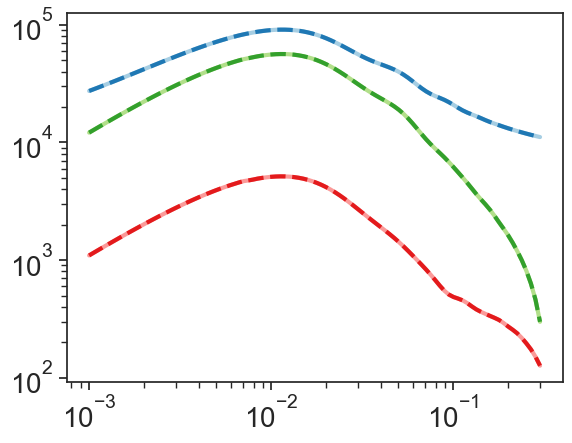

In [7]:
plt.loglog(k, mps['ell0'])
plt.loglog(k, mps_1['ell0'], ls='--')
plt.loglog(k, mps['ell2'])
plt.loglog(k, mps_1['ell2'], ls='--')
plt.loglog(k, mps['ell4'])
plt.loglog(k, mps_1['ell4'], ls='--')

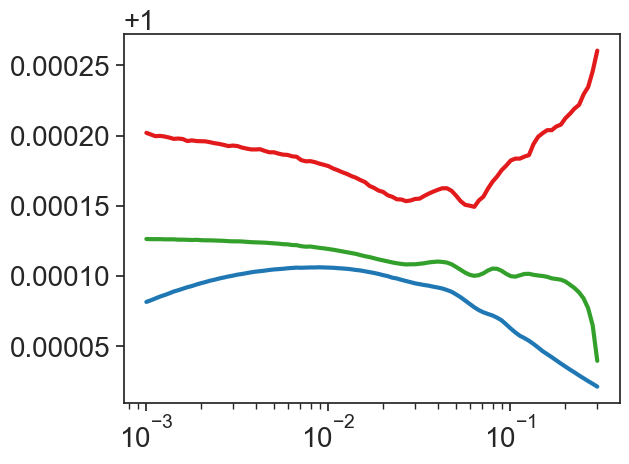

In [8]:
plt.semilogx([],[])
plt.semilogx(k, mps_1['ell0']/mps['ell0'])
plt.semilogx([],[])
plt.semilogx(k, mps_1['ell2']/mps['ell2'])
plt.semilogx([],[])
plt.semilogx(k, mps_1['ell4']/mps['ell4'])

In [9]:
parameters['As'] = 1e-9
parameters_comet = transform_dict(parameters)
mps = mps_spectro.power_multipoles_comet(k=k, parameters=parameters_comet)
print ('-----')
mps_1 = mps_spectro.power_multipoles(k=k, parameters=parameters, ells=[0,2,4])

-----
Note: redshifts have been re-sorted (earliest first)


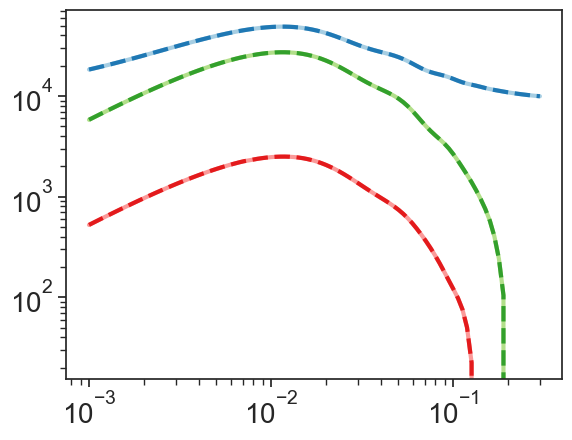

In [10]:
plt.loglog(k, mps['ell0'])
plt.loglog(k, mps_1['ell0'], ls='--')
plt.loglog(k, mps['ell2'])
plt.loglog(k, mps_1['ell2'], ls='--')
plt.loglog(k, mps['ell4'])
plt.loglog(k, mps_1['ell4'], ls='--')

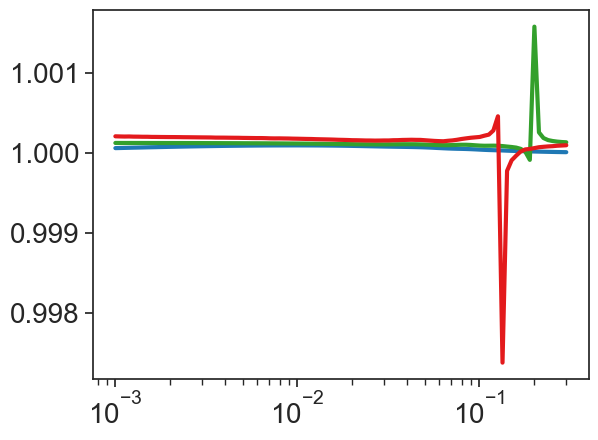

In [11]:
plt.semilogx([],[])
plt.semilogx(k, mps_1['ell0']/mps['ell0'])
plt.semilogx([],[])
plt.semilogx(k, mps_1['ell2']/mps['ell2'])
plt.semilogx([],[])
plt.semilogx(k, mps_1['ell4']/mps['ell4'])

In [12]:
parameters['As'] = 2.1e-9
parameters['H0'] = 90.0
parameters_comet = transform_dict(parameters)
mps = mps_spectro.power_multipoles_comet(k=k, parameters=parameters_comet)
print ('-------')
mps_1 = mps_spectro.power_multipoles(k=k, parameters=parameters, ells=[0,2,4])

-------
Note: redshifts have been re-sorted (earliest first)


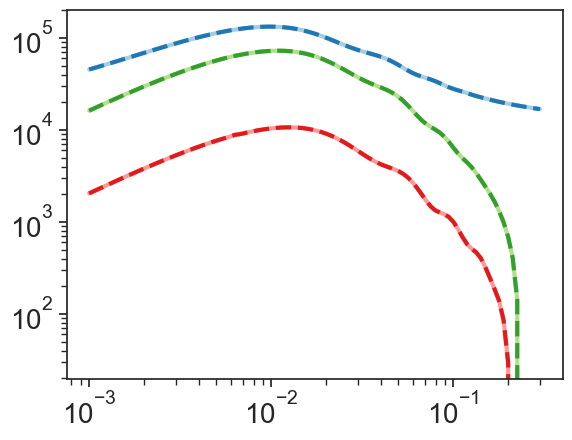

In [13]:
plt.loglog(k, mps['ell0'])
plt.loglog(k, mps_1['ell0'], ls='--')
plt.loglog(k, mps['ell2'])
plt.loglog(k, mps_1['ell2'], ls='--')
plt.loglog(k, mps['ell4'])
plt.loglog(k, mps_1['ell4'], ls='--')

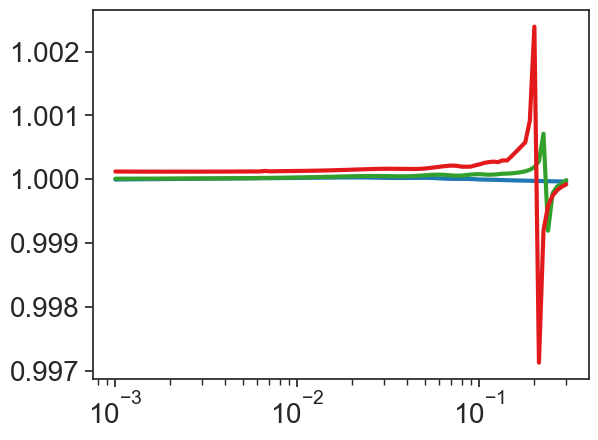

In [14]:
plt.semilogx([],[])
plt.semilogx(k, mps_1['ell0']/mps['ell0'])
plt.semilogx([],[])
plt.semilogx(k, mps_1['ell2']/mps['ell2'])
plt.semilogx([],[])
plt.semilogx(k, mps_1['ell4']/mps['ell4'])

In [17]:
parameters['H0'] = 69.5
parameters['omch2'] = 0.15
parameters_comet = transform_dict(parameters)
mps = mps_spectro.power_multipoles_comet(k=k, parameters=parameters_comet)
print ('-------')
mps_1 = mps_spectro.power_multipoles(k=k, parameters=parameters, ells=[0,2,4])

-------
Note: redshifts have been re-sorted (earliest first)


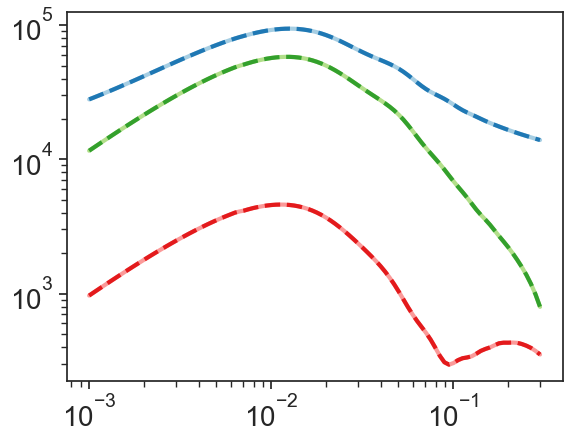

In [18]:
plt.loglog(k, mps['ell0'])
plt.loglog(k, mps_1['ell0'], ls='--')
plt.loglog(k, mps['ell2'])
plt.loglog(k, mps_1['ell2'], ls='--')
plt.loglog(k, mps['ell4'])
plt.loglog(k, mps_1['ell4'], ls='--')

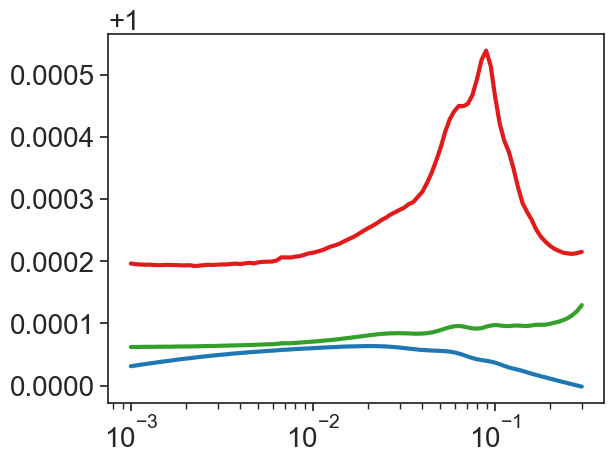

In [19]:
plt.semilogx([],[])
plt.semilogx(k, mps_1['ell0']/mps['ell0'])
plt.semilogx([],[])
plt.semilogx(k, mps_1['ell2']/mps['ell2'])
plt.semilogx([],[])
plt.semilogx(k, mps_1['ell4']/mps['ell4'])

In [20]:
data_reader = reader.DataReader('../../cloelite/input/data.yaml')
data_reader.read_GCspectro()
data = data_reader.data_dict

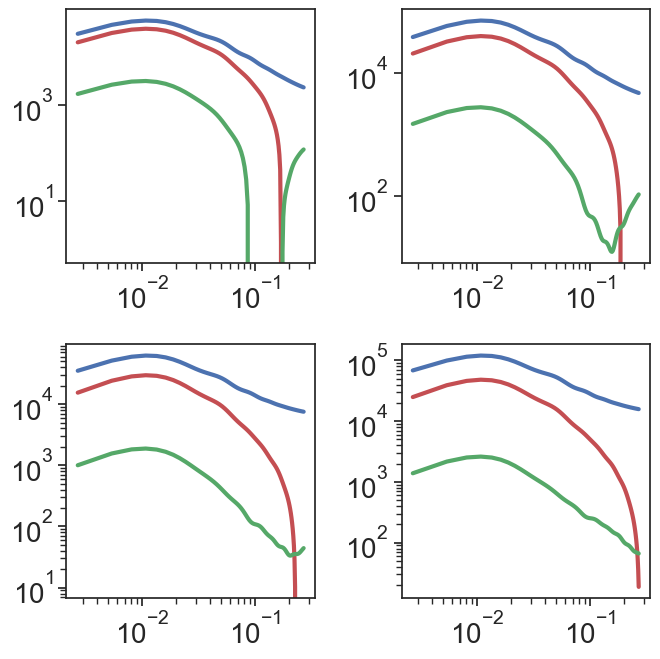

In [21]:
fig, axs = plt.subplots(2, 2, figsize=(7,7))

for i,z in enumerate(['1.', '1.2', '1.4', '1.65']):
    ix = int(np.floor(i/2))
    iy = i%2
    axs[ix,iy].loglog(data['GCspectro'][z]['k'], data['GCspectro'][z]['pk0'], c='b')
    axs[ix,iy].loglog(data['GCspectro'][z]['k'], data['GCspectro'][z]['pk2'], c='r')
    axs[ix,iy].loglog(data['GCspectro'][z]['k'], data['GCspectro'][z]['pk4'], c='g')

plt.tight_layout()

In [22]:
from cloelite.masking import masking

obs_spec_reader = reader.ObsSpecReader('../../cloelite/input/observable_specifications.yaml')
obs_spec = obs_spec_reader.get_full_config()

mask = masking.Masking(data, obs_spec)

In [24]:
redshifts = [float(x) for x in data_reader.data['GCspectro']['redshifts']]
nbar = np.array([2.042611E-03, 1.02876011E-03, 0.58531983E-03, 0.313402E-03]) * 0.67**3

theory_vec = []
for i,z in enumerate(redshifts):
    parameters = params_reader.get_section('cosmology') | params_reader.get_section('GCsp.theory', i) | params_reader.get_section('GCsp.systematics', i)
    parameters['z'] = z
    #parameters_comet = transform_dict(parameters)
    #parameters_comet_fid = deepcopy(parameters_comet)
    #mps_spectro.set_fiducial_cosmology_comet(parameters_comet_fid)
    #mps_spectro.comet_inst.define_nbar(nbar=nbar[i])
    mps_spectro.set_number_density(nbar=nbar[i])
    #mps = mps_spectro.power_multipoles(k=k, parameters=parameters_comet)
    mps_1 = mps_spectro.power_multipoles(k=data['GCspectro'][data_reader.data['GCspectro']['redshifts'][i]]['k'], parameters=parameters, ells=[0,2,4])
    for ell in [0,2,4]:
        theory_vec = np.concatenate((theory_vec, mps_1[f'ell{ell}']))

Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)


In [25]:
data_vec_masked = mask.get_masked_data_vector_GCspectro()
theory_vec_masked = mask.get_masked_theory_vector_GCspectro(theory_vec)

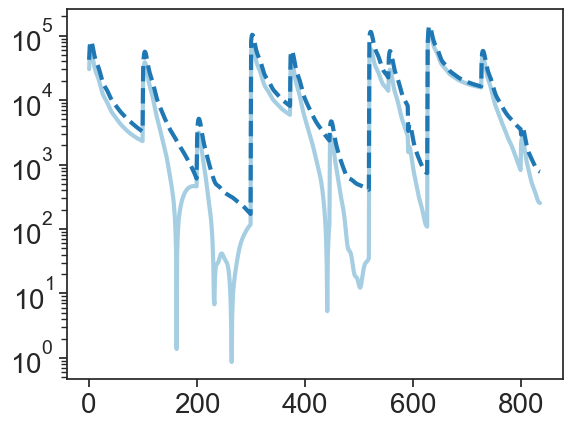

In [26]:
plt.semilogy(abs(data_vec_masked))
plt.semilogy(abs(theory_vec_masked), ls='--')